In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
# Load Dataset

df = pd.read_csv("customers.csv")

print("First 5 Rows:")
print(df.head())

First 5 Rows:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669  9656     7561     214              2674   
1        2       3   7057  9810     9568    1762              3293   
2        2       3   6353  8808     7684    2405              3516   
3        1       3  13265  1196     4221    6404               507   
4        2       3  22615  5410     7198    3915              1777   

   Delicatessen  
0          1338  
1          1776  
2          7844  
3          1788  
4          5185  


In [3]:
# Check Dataset

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Shape:
(440, 8)

Columns:
['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicatessen']

Data Types:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicatessen        int64
dtype: object

Missing Values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicatessen        0
dtype: int64

Duplicate Rows:
0


In [4]:
# Check Target

print("\nChannel Distribution:")
print(df["Channel"].value_counts())

print("\nChannel Percentage:")
print(df["Channel"].value_counts(normalize=True) * 100)


Channel Distribution:
Channel
1    298
2    142
Name: count, dtype: int64

Channel Percentage:
Channel
1    67.727273
2    32.272727
Name: proportion, dtype: float64


In [5]:
# Separate X and y

X = df.drop("Channel", axis=1)
y = df["Channel"]

print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)


X Shape:
(440, 7)

y Shape:
(440,)


In [6]:
# Check Categorical and Numerical Columns

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_columns = X.select_dtypes(
    include=[np.number]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)


Categorical Columns:
[]

Numerical Columns:
['Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicatessen']


In [7]:
# Handle Missing Values

for column in numerical_columns:
    X[column] = X[column].fillna(
        X[column].median()
    )

for column in categorical_columns:
    X[column] = X[column].fillna(
        X[column].mode()[0]
    )

print("\nMissing Values after Handling:")
print(X.isnull().sum())


Missing Values after Handling:
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicatessen        0
dtype: int64


In [8]:
# Encode Categorical Variables

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("\nData after Encoding:")
print(X.head())

print("\nColumns after Encoding:")
print(X.columns.tolist())


Data after Encoding:
   Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicatessen
0       3  12669  9656     7561     214              2674          1338
1       3   7057  9810     9568    1762              3293          1776
2       3   6353  8808     7684    2405              3516          7844
3       3  13265  1196     4221    6404               507          1788
4       3  22615  5410     7198    3915              1777          5185

Columns after Encoding:
['Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicatessen']


In [9]:
# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:")
print(X_train.shape)

print("\nTesting Data:")
print(X_test.shape)


Training Data:
(352, 7)

Testing Data:
(88, 7)


In [10]:
# Random Forest Model

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [11]:
# Make Predictions

y_pred = rf.predict(X_test)


In [12]:
# Evaluate Model

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\nRandom Forest Results:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


Random Forest Results:
Accuracy : 0.9318181818181818
Precision: 0.9318181818181818
Recall   : 0.9318181818181818
F1 Score : 0.9318181818181818


In [13]:
# Classification Report

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

           1       0.95      0.95      0.95        60
           2       0.89      0.89      0.89        28

    accuracy                           0.93        88
   macro avg       0.92      0.92      0.92        88
weighted avg       0.93      0.93      0.93        88



In [14]:
# Confusion Matrix

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)


Confusion Matrix:
[[57  3]
 [ 3 25]]


In [15]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
            Feature  Importance
5  Detergents_Paper    0.391146
3           Grocery    0.250072
2              Milk    0.170107
4            Frozen    0.067731
6      Delicatessen    0.060123
1             Fresh    0.051148
0            Region    0.009673


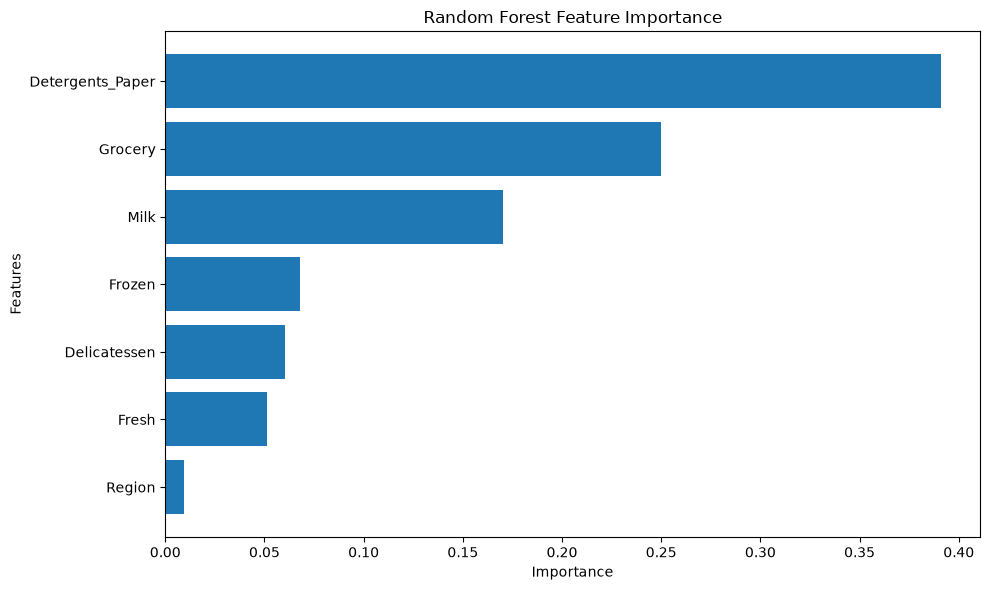

In [16]:
# Plot Feature Importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [17]:
# Check Class Imbalance

class_percentage = (
    y.value_counts(normalize=True) * 100
)

print("\nClass Distribution:")
print(class_percentage)

difference = (
    class_percentage.max()
    - class_percentage.min()
)

if difference > 20:
    print("\nThe dataset has class imbalance.")
    print(
        "Using class_weight='balanced' helps give more "
        "importance to the minority class."
    )
else:
    print("\nThe classes are relatively balanced.")


Class Distribution:
Channel
1    67.727273
2    32.272727
Name: proportion, dtype: float64

The dataset has class imbalance.
Using class_weight='balanced' helps give more importance to the minority class.


In [18]:
# Conclusion

print("\nConclusion:")

print(
    "Random Forest can handle both numerical and encoded "
    "categorical features, but categorical variables need "
    "to be converted into numerical form."
)

print(
    "Missing numerical values can be handled using the median, "
    "while missing categorical values can be replaced using "
    "the mode."
)

print(
    "Random Forest can handle a large number of features, "
    "but irrelevant features can still affect model complexity "
    "and interpretation."
)

print(
    "Feature importance can be used to understand which "
    "features contribute most to the predictions."
)

print(
    "For imbalanced data, class_weight='balanced' can help "
    "the model pay more attention to the minority class."
)

print(
    "Accuracy should not be considered alone when the classes "
    "are imbalanced. Precision, recall and F1 Score should "
    "also be considered."
)


Conclusion:
Random Forest can handle both numerical and encoded categorical features, but categorical variables need to be converted into numerical form.
Missing numerical values can be handled using the median, while missing categorical values can be replaced using the mode.
Random Forest can handle a large number of features, but irrelevant features can still affect model complexity and interpretation.
Feature importance can be used to understand which features contribute most to the predictions.
For imbalanced data, class_weight='balanced' can help the model pay more attention to the minority class.
Accuracy should not be considered alone when the classes are imbalanced. Precision, recall and F1 Score should also be considered.
